In [1]:
import sqlite3
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

✔ Listings  : 20,604 registros
✔ Calendar  : 165,345 registros
✔ Reviews   : 27,892 registros

── BLOQUE A: Oferta y precio ─────────────────


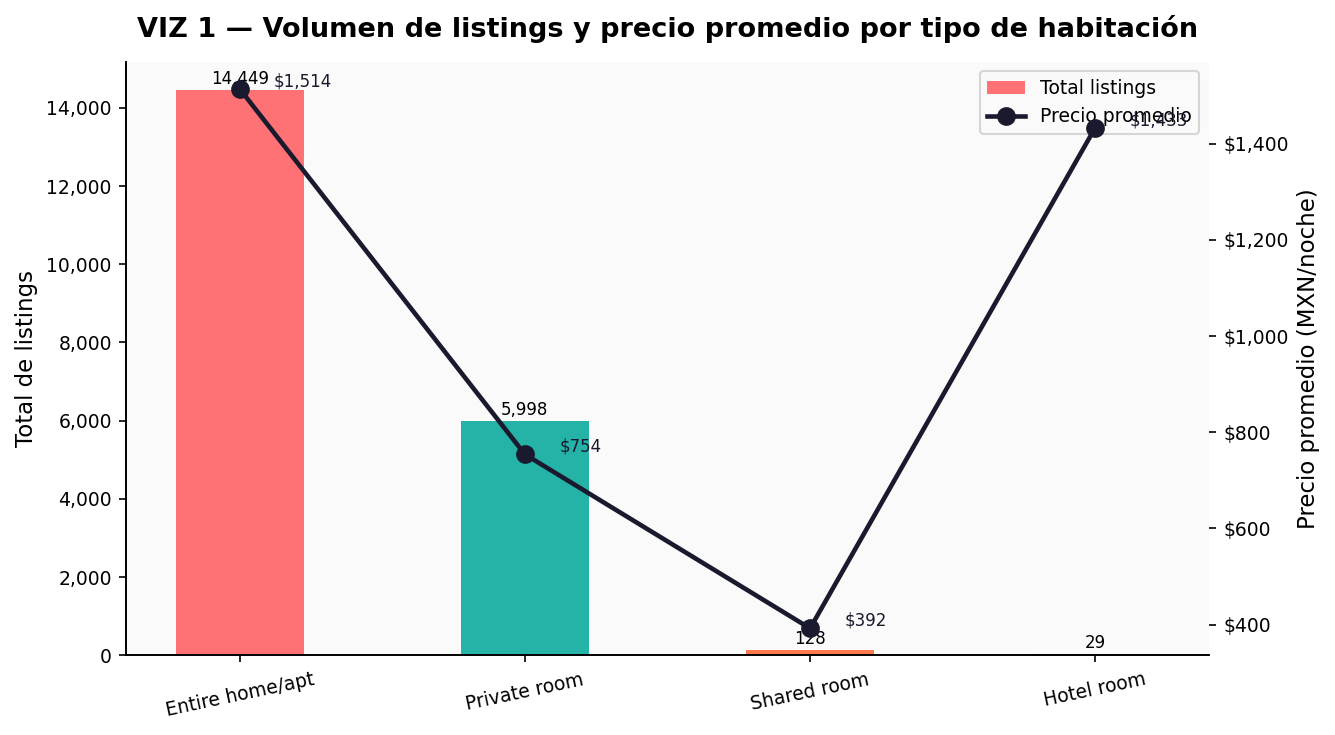

→ Guardado: viz1_volumen_precio_roomtype.png



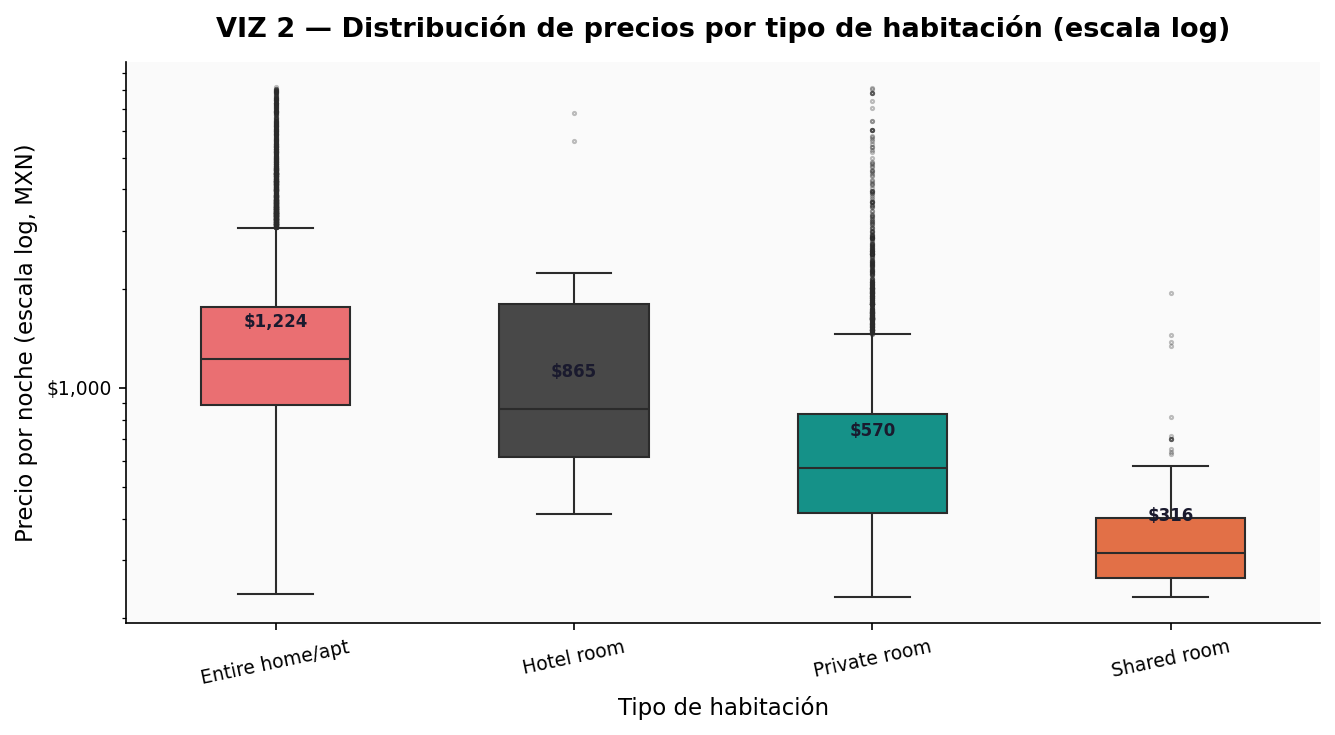

→ Guardado: viz2_boxplot_precio_roomtype.png



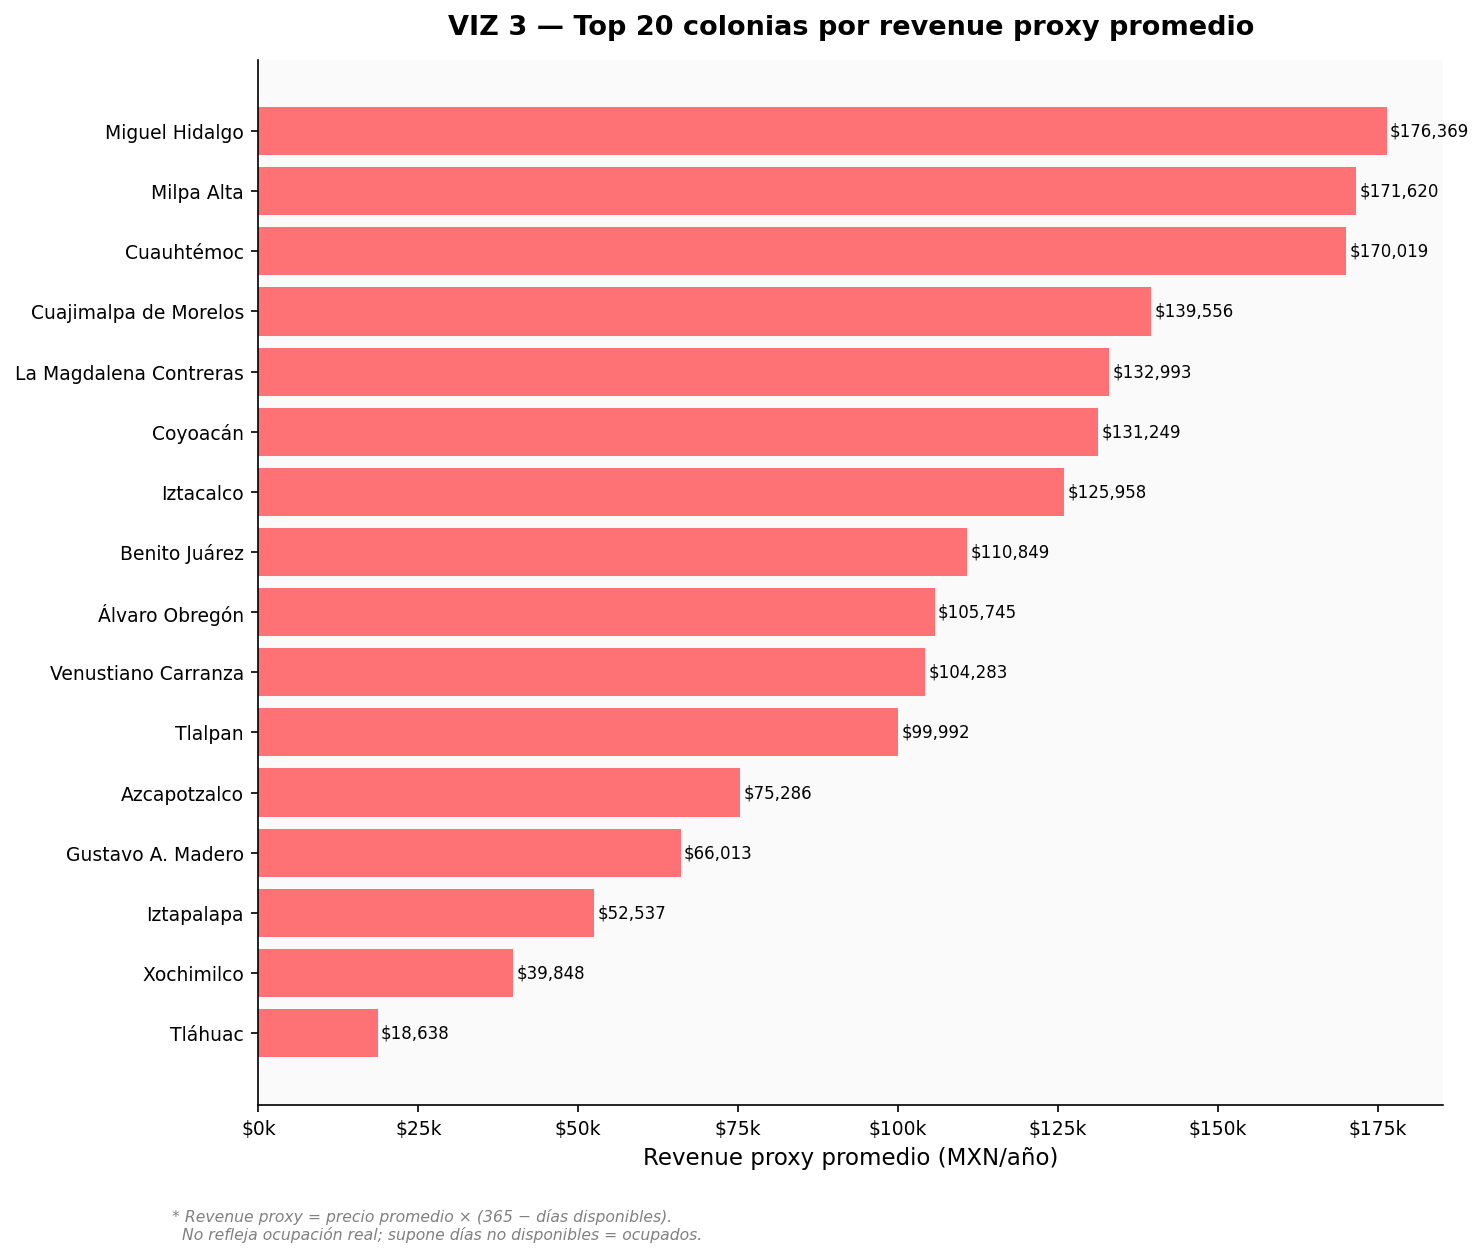

→ Guardado: viz3_top20_colonias_revenue.png


── BLOQUE B: Análisis geográfico ─────────────


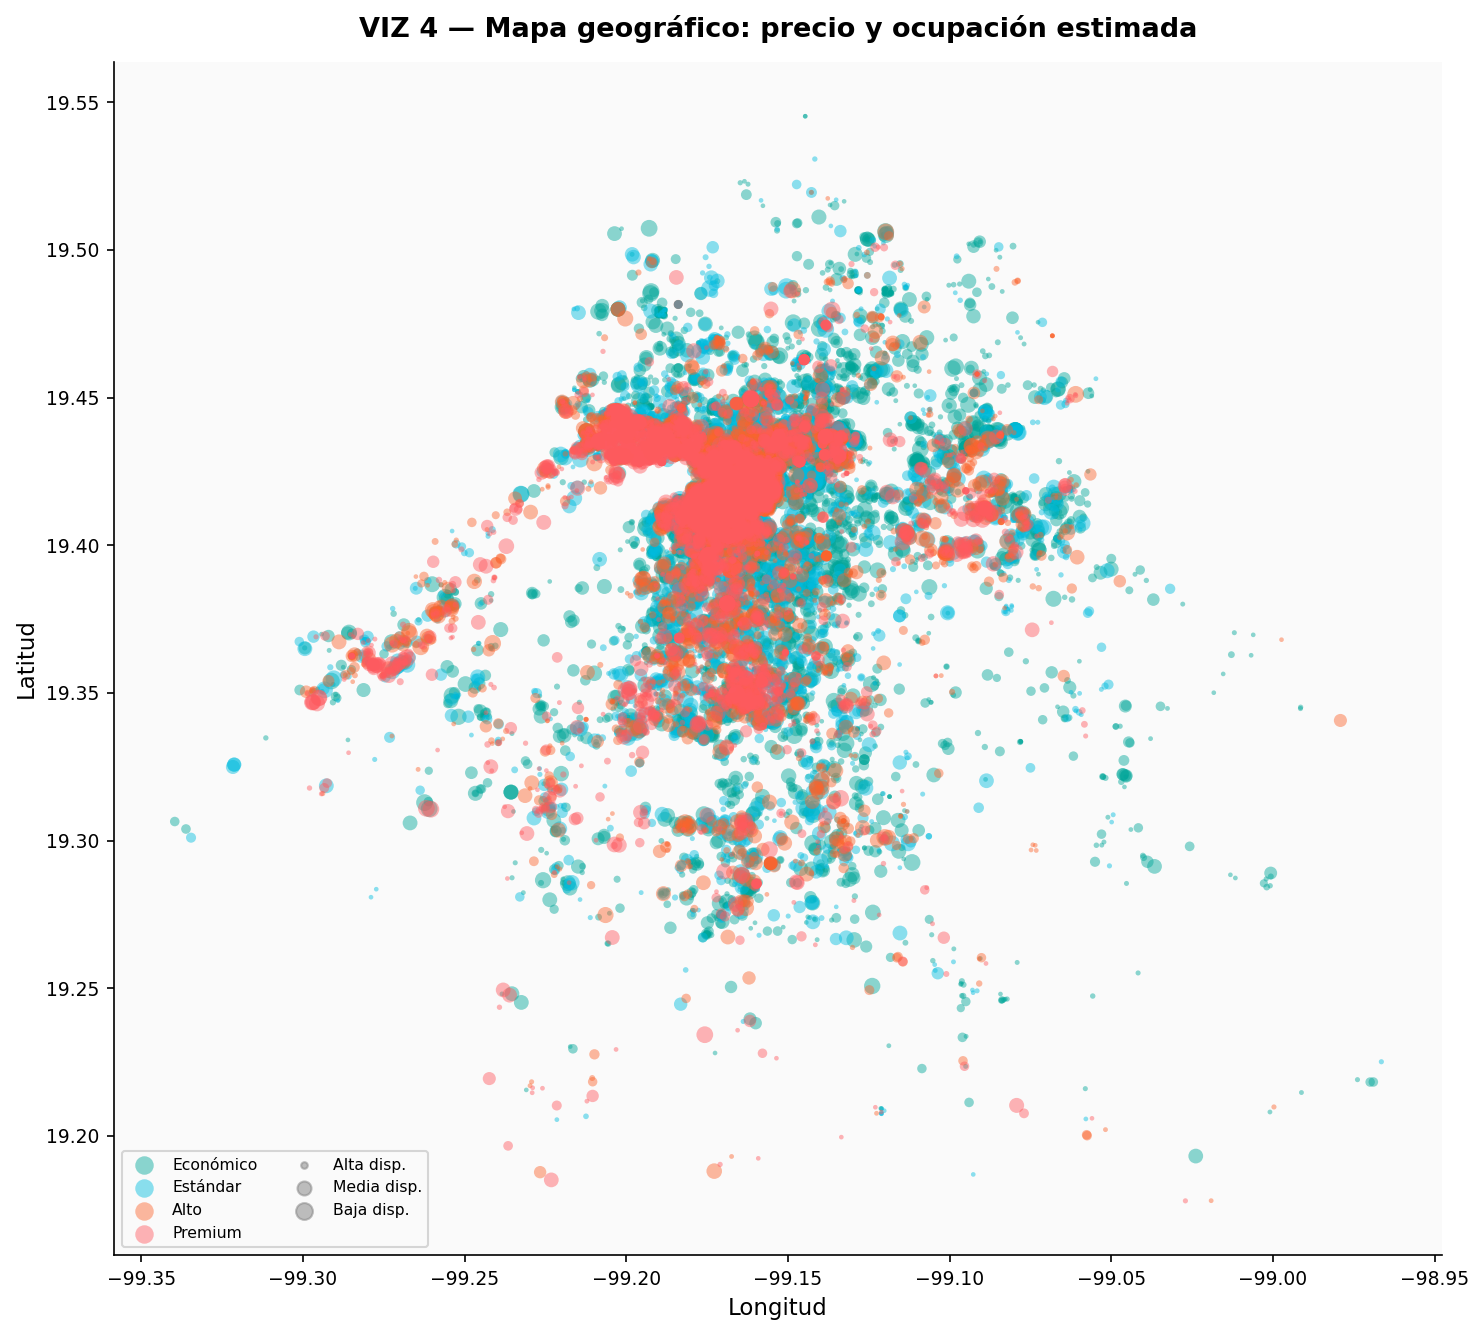

→ Guardado: viz4_mapa_geografico.png



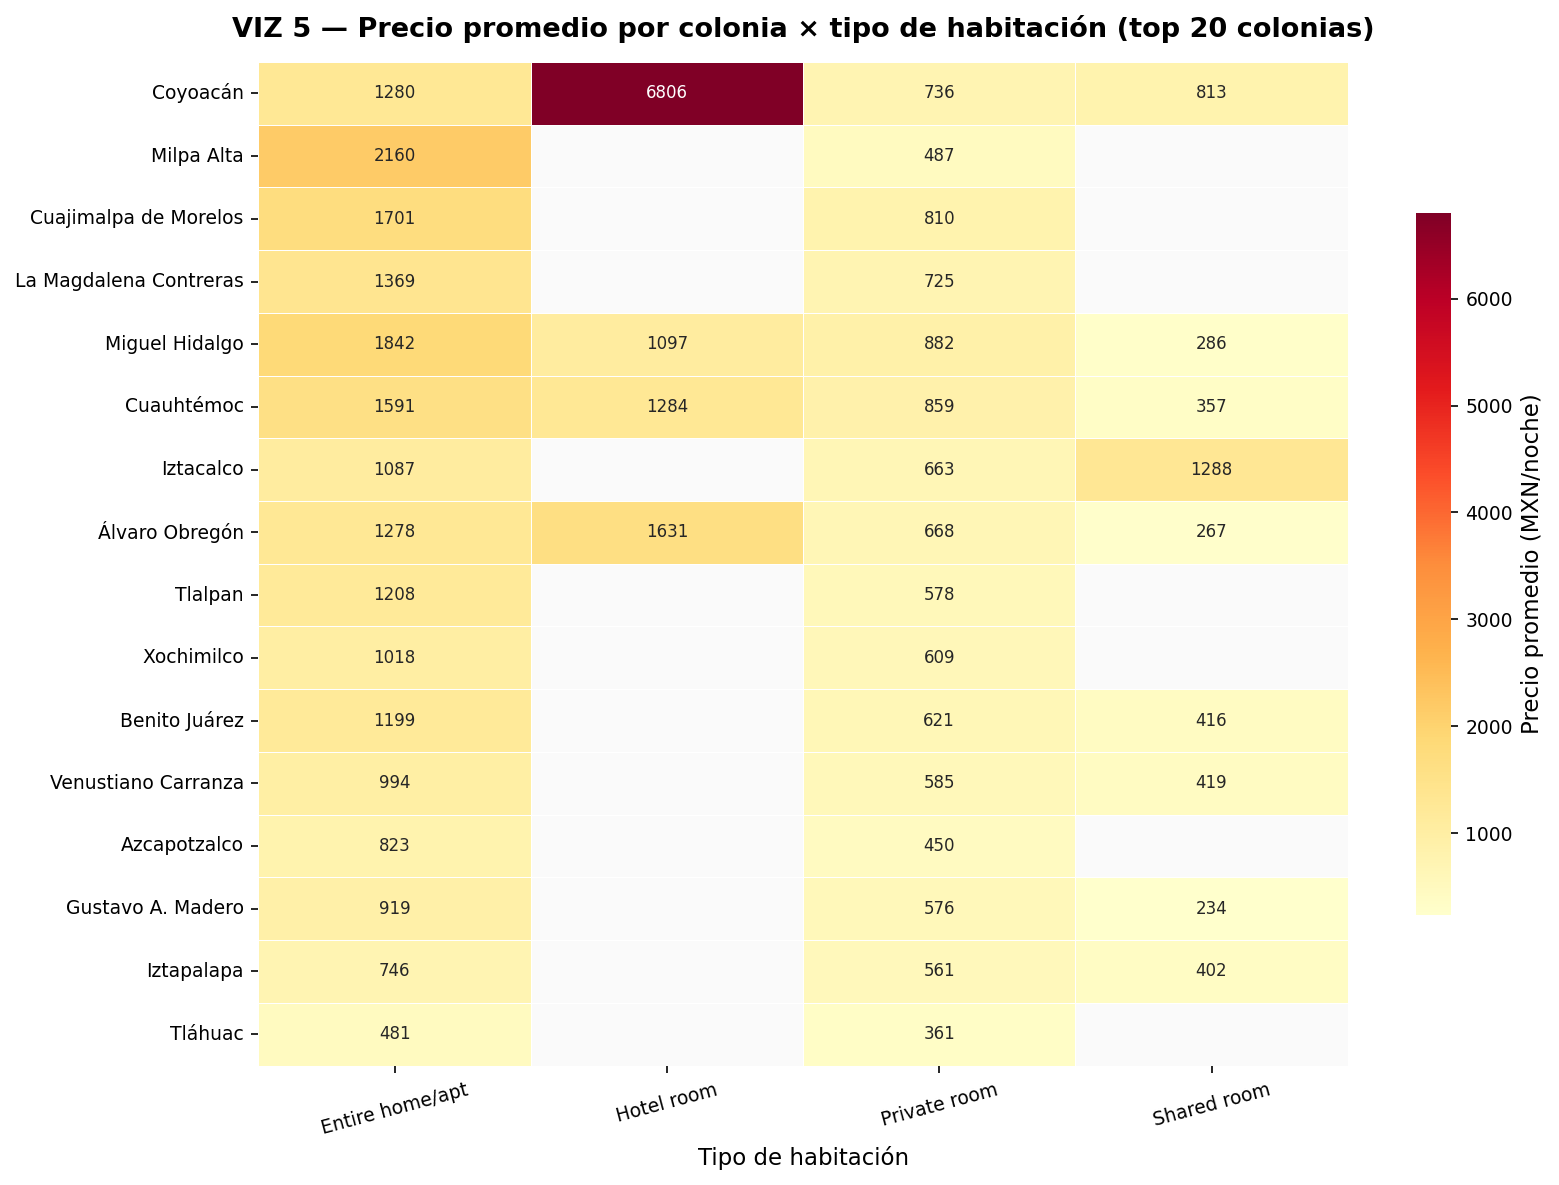

→ Guardado: viz5_heatmap_precio_colonia_roomtype.png


── BLOQUE C: Perfil de anfitrión ─────────────


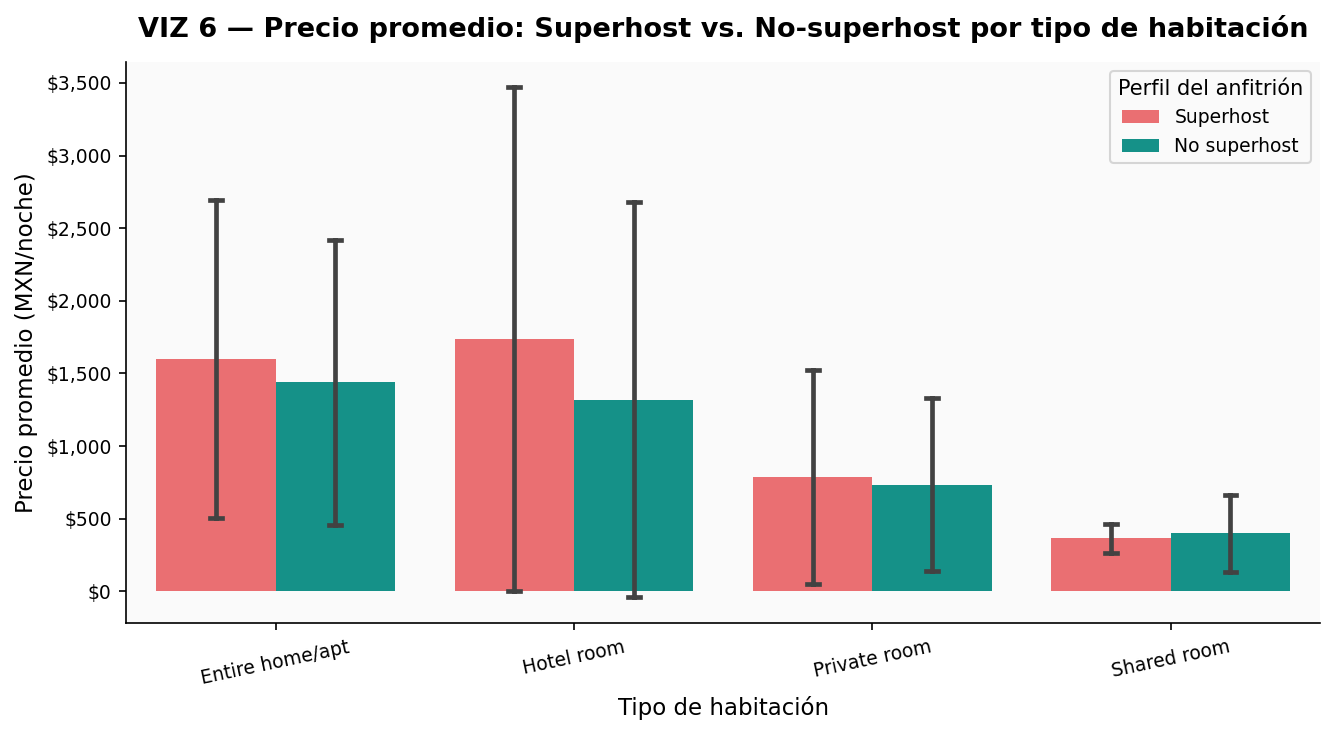

→ Guardado: viz6_superhost_precio_roomtype.png



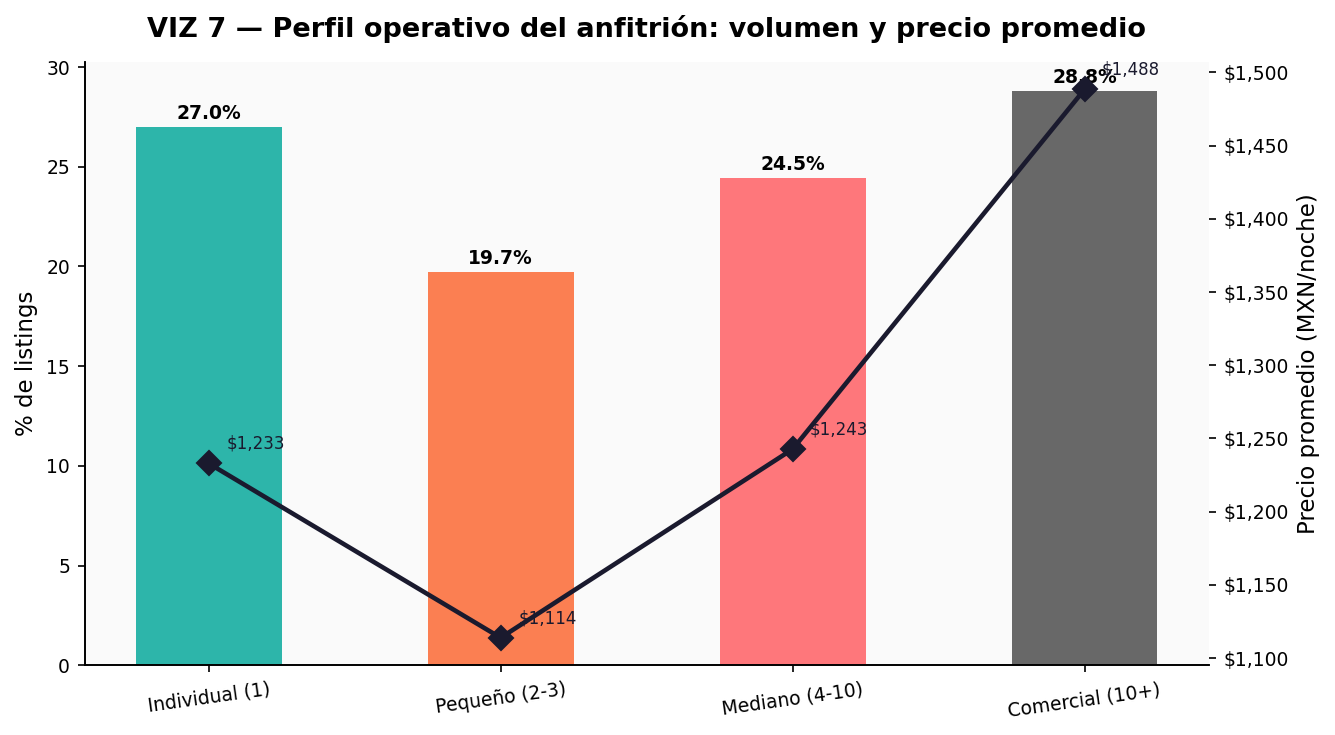

→ Guardado: viz7_perfil_operativo_anfitrion.png


── BLOQUE D: K-Means ─────────────────────────
⚠  Columna 'cluster' no encontrada. Ejecutando K-Means con k=4...


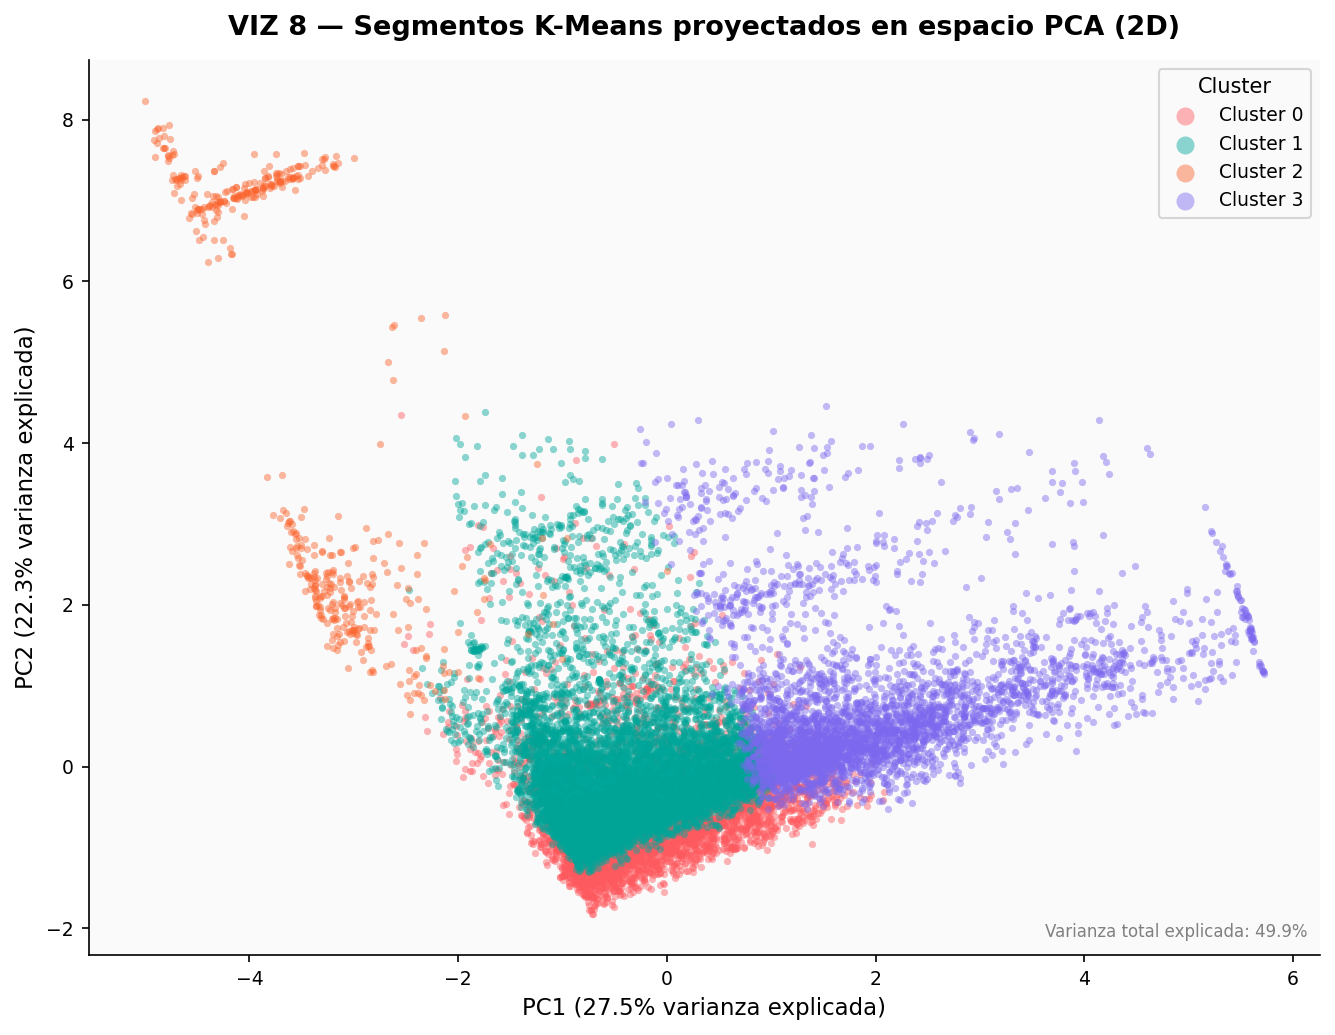

→ Guardado: viz8_clusters_pca.png



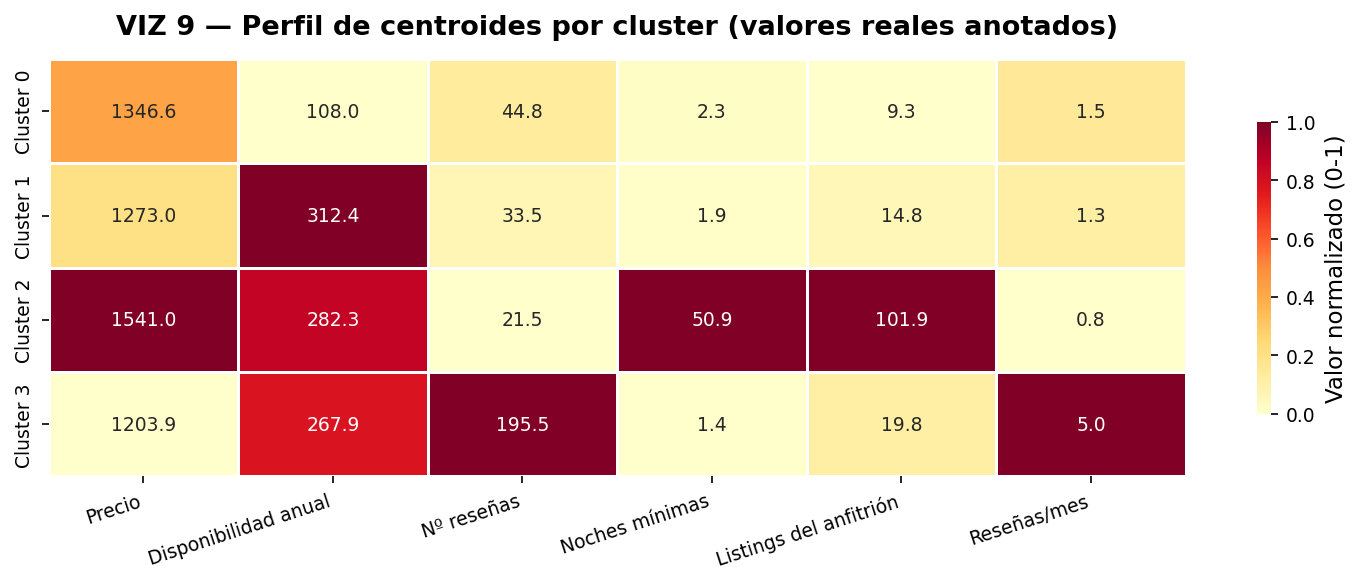

→ Guardado: viz9_centroides_heatmap.png



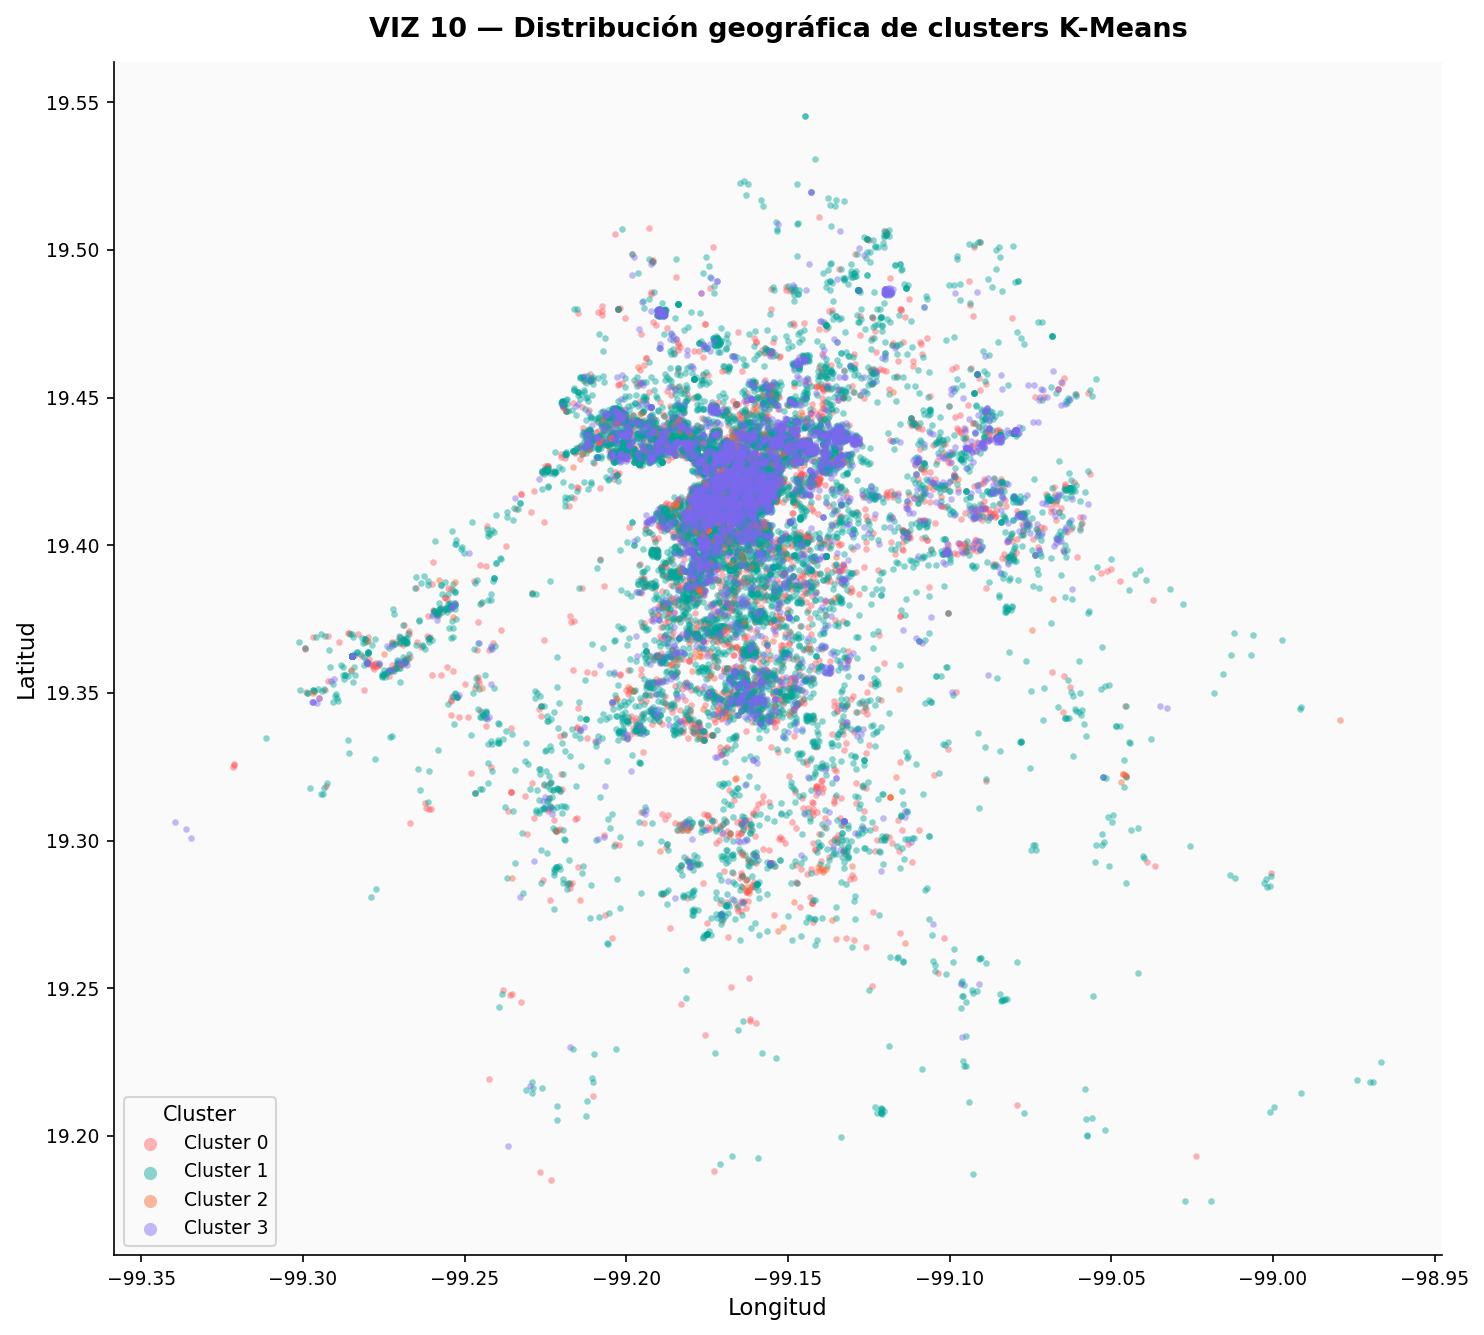

→ Guardado: viz10_mapa_clusters.png


✔ Todas las visualizaciones generadas y guardadas.


In [2]:
"""
visualizaciones_airbnb_cdmx.py
================================
Genera las 10 visualizaciones del Trabajo Final de Inteligencia de Negocios
aplicadas al dataset Airbnb CDMX (2025-09-27).

Fuente de datos: SQLite generado por el pipeline ETL (airbnb.db)
Tablas requeridas: Listings, Calendar, Reviews

Dependencias:
    pip install pandas matplotlib seaborn scikit-learn numpy

Uso en notebook:
    %run visualizaciones_airbnb_cdmx.py
    # o importar funciones individuales:
    from visualizaciones_airbnb_cdmx import cargar_datos, viz1_volumen_precio_room_type, ...
"""


# ─────────────────────────────────────────────
# CONFIGURACIÓN GLOBAL
# ─────────────────────────────────────────────

DB_PATH = "../src/data/airbnb.db"          # Ajustar si la ruta cambia

PALETTE_ROOM = {
    "Entire home/apt":   "#FF5A5F",
    "Private room":      "#00A699",
    "Shared room":       "#FC642D",
    "Hotel room":        "#484848",
}

CLUSTER_PALETTE = ["#FF5A5F", "#00A699", "#FC642D", "#7B68EE", "#FFB400"]

plt.rcParams.update({
    "figure.dpi":        150,
    "figure.facecolor":  "white",
    "axes.facecolor":    "#FAFAFA",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
})


# ─────────────────────────────────────────────
# 0. CARGA DE DATOS
# ─────────────────────────────────────────────

def cargar_datos(db_path: str = DB_PATH) -> dict[str, pd.DataFrame]:
    """
    Lee las tablas Listings, Calendar y Reviews desde SQLite.
    Retorna un diccionario con DataFrames listos para análisis.
    """
    conn = sqlite3.connect(db_path)

    listings = pd.read_sql("SELECT * FROM Listings", conn)
    calendar = pd.read_sql("SELECT * FROM Calendar", conn)
    reviews  = pd.read_sql("SELECT * FROM Reviews",  conn)

    conn.close()

    # ── Limpieza defensiva de price en Listings ──────────────────────────
    if listings["price"].dtype == object:
        listings["price"] = (
            listings["price"]
            .astype(str)
            .str.replace(r"[$,]", "", regex=True)
            .pipe(pd.to_numeric, errors="coerce")
        )

    # ── Filtros de outliers para precio ──────────────────────────────────
    q_low  = listings["price"].quantile(0.01)
    q_high = listings["price"].quantile(0.99)
    listings = listings[listings["price"].between(q_low, q_high)].copy()

    # ── Columnas auxiliares ───────────────────────────────────────────────
    listings["revenue_proxy"] = listings["price"] * (
        365 - listings["availability_365"].fillna(365)
    )

    listings["host_profile"] = pd.cut(
        listings["calculated_host_listings_count"].fillna(1),
        bins=[0, 1, 3, 10, np.inf],
        labels=["Individual (1)", "Pequeño (2-3)", "Mediano (4-10)", "Comercial (10+)"],
    )

    print(f"✔ Listings  : {len(listings):,} registros")
    print(f"✔ Calendar  : {len(calendar):,} registros")
    print(f"✔ Reviews   : {len(reviews):,} registros")

    return {"listings": listings, "calendar": calendar, "reviews": reviews}


# ─────────────────────────────────────────────
# BLOQUE A — Oferta y precio por tipo de habitación
# ─────────────────────────────────────────────

def viz1_volumen_precio_room_type(listings: pd.DataFrame) -> None:
    """
    VIZ 1 — Distribución de listings y precio promedio por tipo de habitación.
    Doble eje: volumen (izquierdo) y precio promedio (derecho).
    """
    agg = (
        listings.groupby("room_type", observed=True)
        .agg(total_listings=("id", "count"), avg_price=("price", "mean"))
        .sort_values("total_listings", ascending=False)
        .reset_index()
    )

    x      = np.arange(len(agg))
    width  = 0.45
    colors = [PALETTE_ROOM.get(r, "#999999") for r in agg["room_type"]]

    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax2 = ax1.twinx()

    bars = ax1.bar(x, agg["total_listings"], width=width, color=colors, alpha=0.85,
                   label="Total listings")
    ax2.plot(x, agg["avg_price"], color="#1a1a2e", marker="o", linewidth=2.2,
             markersize=8, label="Precio promedio")

    # Etiquetas en barras
    for bar in bars:
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                 f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=8)

    # Etiquetas en línea
    for xi, yi in zip(x, agg["avg_price"]):
        ax2.text(xi + 0.12, yi + 5, f"${yi:,.0f}", fontsize=8, color="#1a1a2e")

    ax1.set_xticks(x)
    ax1.set_xticklabels(agg["room_type"], rotation=12)
    ax1.set_ylabel("Total de listings")
    ax2.set_ylabel("Precio promedio (MXN/noche)")
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=9)

    plt.title("VIZ 1 — Volumen de listings y precio promedio por tipo de habitación",
              fontweight="bold", pad=12)
    fig.tight_layout()
    plt.savefig("viz1_volumen_precio_roomtype.png", bbox_inches="tight")
    plt.show()
    print("→ Guardado: viz1_volumen_precio_roomtype.png\n")


def viz2_boxplot_precio_room_type(listings: pd.DataFrame) -> None:
    """
    VIZ 2 — Boxplot de price por room_type con escala log.
    Muestra la dispersión real dentro de cada categoría.
    """
    orden = (
        listings.groupby("room_type", observed=True)["price"]
        .median()
        .sort_values(ascending=False)
        .index.tolist()
    )
    palette = [PALETTE_ROOM.get(r, "#999999") for r in orden]

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.boxplot(
        data=listings,
        x="room_type", y="price",
        order=orden,
        palette=palette,
        width=0.5,
        flierprops=dict(marker=".", markersize=3, alpha=0.3),
        ax=ax,
    )

    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
    ax.set_xlabel("Tipo de habitación")
    ax.set_ylabel("Precio por noche (escala log, MXN)")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=12)

    # Medianas como anotación
    for i, rt in enumerate(orden):
        med = listings[listings["room_type"] == rt]["price"].median()
        ax.text(i, med * 1.25, f"${med:,.0f}", ha="center", fontsize=8,
                fontweight="bold", color="#1a1a2e")

    plt.title("VIZ 2 — Distribución de precios por tipo de habitación (escala log)",
              fontweight="bold", pad=12)
    fig.tight_layout()
    plt.savefig("viz2_boxplot_precio_roomtype.png", bbox_inches="tight")
    plt.show()
    print("→ Guardado: viz2_boxplot_precio_roomtype.png\n")


def viz3_top20_colonias_revenue(listings: pd.DataFrame) -> None:
    """
    VIZ 3 — Top 20 colonias por revenue_proxy promedio.
    revenue_proxy = price × (365 − availability_365)
    """
    top20 = (
        listings.groupby("neighbourhood_cleansed", observed=True)["revenue_proxy"]
        .mean()
        .nlargest(20)
        .reset_index()
        .sort_values("revenue_proxy")
    )

    fig, ax = plt.subplots(figsize=(10, 8))
    bars = ax.barh(top20["neighbourhood_cleansed"], top20["revenue_proxy"],
                   color="#FF5A5F", alpha=0.85)

    for bar in bars:
        w = bar.get_width()
        ax.text(w + 500, bar.get_y() + bar.get_height() / 2,
                f"${w:,.0f}", va="center", fontsize=8)

    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e3:.0f}k"))
    ax.set_xlabel("Revenue proxy promedio (MXN/año)")
    ax.set_ylabel("")

    nota = (
        "* Revenue proxy = precio promedio × (365 − días disponibles).\n"
        "  No refleja ocupación real; supone días no disponibles = ocupados."
    )
    fig.text(0.12, -0.04, nota, fontsize=7.5, color="gray", style="italic")

    plt.title("VIZ 3 — Top 20 colonias por revenue proxy promedio",
              fontweight="bold", pad=12)
    fig.tight_layout()
    plt.savefig("viz3_top20_colonias_revenue.png", bbox_inches="tight")
    plt.show()
    print("→ Guardado: viz3_top20_colonias_revenue.png\n")


# ─────────────────────────────────────────────
# BLOQUE B — Análisis geográfico
# ─────────────────────────────────────────────

def viz4_mapa_geografico(listings: pd.DataFrame) -> None:
    """
    VIZ 4 — Mapa de dispersión geográfico.
    Color: price_rango.  Tamaño: disponibilidad invertida (ocupación estimada).
    """
    df = listings.dropna(subset=["latitude", "longitude", "price_rango",
                                  "availability_365"]).copy()

    # Tamaño del punto: menor disponibilidad → punto más grande
    max_avail = df["availability_365"].max() if df["availability_365"].max() > 0 else 365
    df["point_size"] = ((1 - df["availability_365"] / max_avail) * 60 + 5).clip(5, 65)

    rango_order   = ["Económico", "Estándar", "Alto", "Premium"]
    rango_colors  = ["#00A699", "#00BCDF", "#FC642D", "#FF5A5F"]
    color_map     = dict(zip(rango_order, rango_colors))

    fig, ax = plt.subplots(figsize=(10, 9))

    for rango, color in color_map.items():
        mask = df["price_rango"] == rango
        ax.scatter(
            df.loc[mask, "longitude"], df.loc[mask, "latitude"],
            s=df.loc[mask, "point_size"], c=color, alpha=0.45,
            label=rango, linewidths=0,
        )

    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    ax.legend(title="Rango de precio", loc="lower left", fontsize=8, markerscale=1.5)

    size_legend = [
        plt.scatter([], [], s=10,  c="gray", alpha=0.5, label="Alta disponibilidad"),
        plt.scatter([], [], s=45,  c="gray", alpha=0.5, label="Media disponibilidad"),
        plt.scatter([], [], s=65,  c="gray", alpha=0.5, label="Baja disponibilidad"),
    ]
    ax.legend(handles=ax.get_legend().legend_handles + size_legend,
              labels=rango_order + ["Alta disp.", "Media disp.", "Baja disp."],
              loc="lower left", fontsize=7.5, ncol=2)

    plt.title("VIZ 4 — Mapa geográfico: precio y ocupación estimada",
              fontweight="bold", pad=12)
    fig.tight_layout()
    plt.savefig("viz4_mapa_geografico.png", bbox_inches="tight")
    plt.show()
    print("→ Guardado: viz4_mapa_geografico.png\n")


def viz5_heatmap_precio_colonia_roomtype(listings: pd.DataFrame, top_n: int = 20) -> None:
    """
    VIZ 5 — Heatmap precio promedio por colonia × room_type.
    Filas: top N colonias por volumen de listings.
    """
    top_colonias = (
        listings["neighbourhood_cleansed"].value_counts().head(top_n).index
    )

    pivot = (
        listings[listings["neighbourhood_cleansed"].isin(top_colonias)]
        .groupby(["neighbourhood_cleansed", "room_type"], observed=True)["price"]
        .mean()
        .unstack(fill_value=np.nan)
    )

    # Ordenar colonias por precio promedio general
    pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

    fig, ax = plt.subplots(figsize=(11, 8))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".0f",
        cmap="YlOrRd",
        linewidths=0.4,
        cbar_kws={"label": "Precio promedio (MXN/noche)", "shrink": 0.7},
        ax=ax,
        annot_kws={"size": 8},
    )

    ax.set_xlabel("Tipo de habitación")
    ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
    plt.title(
        f"VIZ 5 — Precio promedio por colonia × tipo de habitación (top {top_n} colonias)",
        fontweight="bold", pad=12,
    )
    fig.tight_layout()
    plt.savefig("viz5_heatmap_precio_colonia_roomtype.png", bbox_inches="tight")
    plt.show()
    print("→ Guardado: viz5_heatmap_precio_colonia_roomtype.png\n")


# ─────────────────────────────────────────────
# BLOQUE C — Perfil de anfitrión
# ─────────────────────────────────────────────

def viz6_superhost_precio_roomtype(listings: pd.DataFrame) -> None:
    """
    VIZ 6 — Precio promedio: superhost vs. no-superhost por room_type.
    """
    df = listings.dropna(subset=["host_is_superhost"]).copy()
    df["superhost_label"] = df["host_is_superhost"].map(
        {"t": "Superhost", "f": "No superhost", True: "Superhost", False: "No superhost"}
    )
    df = df[df["superhost_label"].notna()]

    orden = (
        df.groupby("room_type", observed=True)["price"]
        .mean()
        .sort_values(ascending=False)
        .index.tolist()
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(
        data=df,
        x="room_type", y="price",
        hue="superhost_label",
        order=orden,
        hue_order=["Superhost", "No superhost"],
        palette={"Superhost": "#FF5A5F", "No superhost": "#00A699"},
        errorbar="sd",
        capsize=0.08,
        ax=ax,
    )

    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
    ax.set_xlabel("Tipo de habitación")
    ax.set_ylabel("Precio promedio (MXN/noche)")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=12)
    ax.legend(title="Perfil del anfitrión", fontsize=9)

    plt.title("VIZ 6 — Precio promedio: Superhost vs. No-superhost por tipo de habitación",
              fontweight="bold", pad=12)
    fig.tight_layout()
    plt.savefig("viz6_superhost_precio_roomtype.png", bbox_inches="tight")
    plt.show()
    print("→ Guardado: viz6_superhost_precio_roomtype.png\n")


def viz7_perfil_operativo_anfitrion(listings: pd.DataFrame) -> None:
    """
    VIZ 7 — Distribución de listings por perfil operativo del anfitrión
    y precio promedio por perfil. Doble eje.
    """
    agg = (
        listings.groupby("host_profile", observed=True)
        .agg(total=("id", "count"), avg_price=("price", "mean"))
        .reset_index()
    )
    agg["pct"] = agg["total"] / agg["total"].sum() * 100

    x      = np.arange(len(agg))
    colors = ["#00A699", "#FC642D", "#FF5A5F", "#484848"]

    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax2 = ax1.twinx()

    bars = ax1.bar(x, agg["pct"], color=colors, alpha=0.82, width=0.5)
    ax2.plot(x, agg["avg_price"], color="#1a1a2e", marker="D",
             linewidth=2.2, markersize=8)

    for bar, pct in zip(bars, agg["pct"]):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                 f"{pct:.1f}%", ha="center", fontsize=9, fontweight="bold")

    for xi, yi in zip(x, agg["avg_price"]):
        ax2.text(xi + 0.06, yi + 10, f"${yi:,.0f}", fontsize=8, color="#1a1a2e")

    ax1.set_xticks(x)
    ax1.set_xticklabels(agg["host_profile"], rotation=8)
    ax1.set_ylabel("% de listings")
    ax2.set_ylabel("Precio promedio (MXN/noche)")
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))

    plt.title("VIZ 7 — Perfil operativo del anfitrión: volumen y precio promedio",
              fontweight="bold", pad=12)
    fig.tight_layout()
    plt.savefig("viz7_perfil_operativo_anfitrion.png", bbox_inches="tight")
    plt.show()
    print("→ Guardado: viz7_perfil_operativo_anfitrion.png\n")


# ─────────────────────────────────────────────
# BLOQUE D — K-Means
# ─────────────────────────────────────────────

def preparar_features_kmeans(listings: pd.DataFrame) -> tuple[pd.DataFrame, np.ndarray, StandardScaler]:
    """
    Prepara el subconjunto de features para K-Means.
    Retorna (df_modelo, X_scaled, scaler).
    """
    FEATURES = [
        "price",
        "availability_365",
        "number_of_reviews",
        "minimum_nights",
        "calculated_host_listings_count",
        "reviews_per_month",
    ]

    df = listings[FEATURES].copy()

    # Imputación: mediana por feature
    for col in FEATURES:
        df[col] = df[col].fillna(df[col].median())

    # Winsorización suave (p99) para reducir efecto de outliers en el clustering
    for col in FEATURES:
        upper = df[col].quantile(0.99)
        df[col] = df[col].clip(upper=upper)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df)

    return df, X_scaled, scaler


def viz8_clusters_pca(listings: pd.DataFrame, cluster_col: str = "cluster") -> None:
    """
    VIZ 8 — Scatter PCA 2D coloreado por cluster.
    Requiere que listings tenga la columna cluster_col (generada por el notebook K-Means).
    Si no existe, ejecuta K-Means con k=4 automáticamente.
    """
    from sklearn.cluster import KMeans

    df_feat, X_scaled, _ = preparar_features_kmeans(listings)

    if cluster_col not in listings.columns:
        print("⚠  Columna 'cluster' no encontrada. Ejecutando K-Means con k=4...")
        km = KMeans(n_clusters=4, random_state=42, n_init=10)
        listings[cluster_col] = km.fit_predict(X_scaled)

    pca    = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X_scaled)

    var_exp = pca.explained_variance_ratio_ * 100
    labels  = listings.loc[df_feat.index, cluster_col].values

    fig, ax = plt.subplots(figsize=(9, 7))
    for cl in sorted(np.unique(labels)):
        mask = labels == cl
        ax.scatter(
            coords[mask, 0], coords[mask, 1],
            s=12, alpha=0.45, linewidths=0,
            color=CLUSTER_PALETTE[cl % len(CLUSTER_PALETTE)],
            label=f"Cluster {cl}",
        )

    ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}% varianza explicada)")
    ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}% varianza explicada)")
    ax.legend(title="Cluster", fontsize=9, markerscale=2.5)

    total_var = sum(var_exp)
    ax.text(0.99, 0.02, f"Varianza total explicada: {total_var:.1f}%",
            transform=ax.transAxes, ha="right", fontsize=8, color="gray")

    plt.title("VIZ 8 — Segmentos K-Means proyectados en espacio PCA (2D)",
              fontweight="bold", pad=12)
    fig.tight_layout()
    plt.savefig("viz8_clusters_pca.png", bbox_inches="tight")
    plt.show()
    print("→ Guardado: viz8_clusters_pca.png\n")


def viz9_centroides_heatmap(listings: pd.DataFrame, cluster_col: str = "cluster") -> None:
    """
    VIZ 9 — Heatmap normalizado de centroides por cluster.
    Muestra qué variable caracteriza a cada segmento.
    """
    from sklearn.cluster import KMeans

    FEATURES = [
        "price",
        "availability_365",
        "number_of_reviews",
        "minimum_nights",
        "calculated_host_listings_count",
        "reviews_per_month",
    ]
    FEATURES_LABELS = {
        "price":                            "Precio",
        "availability_365":                 "Disponibilidad anual",
        "number_of_reviews":                "Nº reseñas",
        "minimum_nights":                   "Noches mínimas",
        "calculated_host_listings_count":   "Listings del anfitrión",
        "reviews_per_month":                "Reseñas/mes",
    }

    df_feat, X_scaled, scaler = preparar_features_kmeans(listings)

    if cluster_col not in listings.columns:
        km = KMeans(n_clusters=4, random_state=42, n_init=10)
        listings[cluster_col] = km.fit_predict(X_scaled)

    # Centroides en escala original (sin estandarizar) normalizados 0-1
    centroids_raw = (
        listings.loc[df_feat.index, FEATURES + [cluster_col]]
        .groupby(cluster_col)[FEATURES]
        .mean()
    )
    centroids_norm = (centroids_raw - centroids_raw.min()) / (
        centroids_raw.max() - centroids_raw.min() + 1e-9
    )
    centroids_norm.columns = [FEATURES_LABELS[c] for c in centroids_norm.columns]
    centroids_norm.index   = [f"Cluster {i}" for i in centroids_norm.index]

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.heatmap(
        centroids_norm,
        annot=centroids_raw.rename(columns=FEATURES_LABELS).values,
        fmt=".1f",
        cmap="YlOrRd",
        linewidths=0.5,
        cbar_kws={"label": "Valor normalizado (0-1)", "shrink": 0.7},
        ax=ax,
        annot_kws={"size": 9},
    )

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=18, ha="right")

    plt.title("VIZ 9 — Perfil de centroides por cluster (valores reales anotados)",
              fontweight="bold", pad=12)
    fig.tight_layout()
    plt.savefig("viz9_centroides_heatmap.png", bbox_inches="tight")
    plt.show()
    print("→ Guardado: viz9_centroides_heatmap.png\n")


def viz10_mapa_clusters(listings: pd.DataFrame, cluster_col: str = "cluster") -> None:
    """
    VIZ 10 — Mapa geográfico de puntos coloreado por cluster asignado.
    Permite evaluar si los segmentos tienen coherencia espacial.
    """
    from sklearn.cluster import KMeans

    df_feat, X_scaled, _ = preparar_features_kmeans(listings)

    if cluster_col not in listings.columns:
        km = KMeans(n_clusters=4, random_state=42, n_init=10)
        listings[cluster_col] = km.fit_predict(X_scaled)

    df = listings.dropna(subset=["latitude", "longitude"]).copy()

    fig, ax = plt.subplots(figsize=(10, 9))
    for cl in sorted(df[cluster_col].unique()):
        mask = df[cluster_col] == cl
        ax.scatter(
            df.loc[mask, "longitude"],
            df.loc[mask, "latitude"],
            s=10, alpha=0.45, linewidths=0,
            color=CLUSTER_PALETTE[int(cl) % len(CLUSTER_PALETTE)],
            label=f"Cluster {cl}",
        )

    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    ax.legend(title="Cluster", loc="lower left", fontsize=9, markerscale=2)

    plt.title("VIZ 10 — Distribución geográfica de clusters K-Means",
              fontweight="bold", pad=12)
    fig.tight_layout()
    plt.savefig("viz10_mapa_clusters.png", bbox_inches="tight")
    plt.show()
    print("→ Guardado: viz10_mapa_clusters.png\n")


# ─────────────────────────────────────────────
# EJECUCIÓN COMPLETA
# ─────────────────────────────────────────────

def generar_todas(db_path: str = DB_PATH) -> None:
    """
    Carga los datos y genera las 10 visualizaciones en secuencia.
    Llama a esta función desde el notebook o desde __main__.
    """
    datos    = cargar_datos(db_path)
    listings = datos["listings"]

    print("\n── BLOQUE A: Oferta y precio ─────────────────")
    viz1_volumen_precio_room_type(listings)
    viz2_boxplot_precio_room_type(listings)
    viz3_top20_colonias_revenue(listings)

    print("\n── BLOQUE B: Análisis geográfico ─────────────")
    viz4_mapa_geografico(listings)
    viz5_heatmap_precio_colonia_roomtype(listings)

    print("\n── BLOQUE C: Perfil de anfitrión ─────────────")
    viz6_superhost_precio_roomtype(listings)
    viz7_perfil_operativo_anfitrion(listings)

    print("\n── BLOQUE D: K-Means ─────────────────────────")
    viz8_clusters_pca(listings)
    viz9_centroides_heatmap(listings)
    viz10_mapa_clusters(listings)

    print("\n✔ Todas las visualizaciones generadas y guardadas.")


if __name__ == "__main__":
    generar_todas()